In [ ]:
!unzip '/content/MyDrive/matmod/matmod-it-psb.zip'

unzip:  cannot find or open /content/MyDrive/matmod/matmod-it-psb.zip, /content/MyDrive/matmod/matmod-it-psb.zip.zip or /content/MyDrive/matmod/matmod-it-psb.zip.ZIP.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip '/content/drive/MyDrive/matmod/matmod-it-psb.zip'

Archive:  /content/drive/MyDrive/matmod/matmod-it-psb.zip
  inflating: companies_info/contracts.csv  
  inflating: companies_info/egrul.csv  
  inflating: companies_info/enforcements.csv  
  inflating: companies_info/finances.csv  
  inflating: companies_info/kad_arbitr.csv  
  inflating: organizations.csv       
  inflating: submission.csv          
  inflating: target_test.csv         
  inflating: target_train.csv        


In [ ]:
import pandas as pd
import re
organizations = pd.read_csv("organizations.csv")
contracts = pd.read_csv("companies_info/contracts.csv")
kad_arbitr =  pd.read_csv("companies_info/kad_arbitr.csv")
finances =  pd.read_csv("companies_info/finances.csv")
enforcements =  pd.read_csv("companies_info/enforcements.csv")
egrul =  pd.read_csv("companies_info/egrul.csv")



In [ ]:
data = organizations


In [ ]:
contracts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6808 entries, 0 to 6807
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          6808 non-null   int64 
 1   inn         6808 non-null   int64 
 2   data        6808 non-null   object
 3   fetched_at  6808 non-null   object
dtypes: int64(2), object(2)
memory usage: 212.9+ KB


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  15000 non-null  int64  
 1   Unnamed: 0    15000 non-null  int64  
 2   id            15000 non-null  int64  
 3   status        15000 non-null  object 
 4   invalid_info  0 non-null      float64
 5   inn           15000 non-null  int64  
 6   name          15000 non-null  object 
 7   region        15000 non-null  object 
 8   okved         15000 non-null  object 
dtypes: float64(1), int64(4), object(4)
memory usage: 1.0+ MB


In [ ]:
data = data.drop(columns=['Unnamed: 0.1', 'Unnamed: 0',"invalid_info","id"])
contracts = contracts.drop(columns=["id"])
kad_arbitr = kad_arbitr.drop(columns=["id"])
finances = finances.drop(columns=["id"])
enforcements = enforcements.drop(columns=["id"])
egrul = egrul.drop(columns=["id"])



In [ ]:
egrul.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   inn         15000 non-null  int64 
 1   data        15000 non-null  object
 2   fetched_at  15000 non-null  object
dtypes: int64(1), object(2)
memory usage: 351.7+ KB


In [ ]:
data

,status,inn,name,region,okved
0,Действующая организация,5260112410,"ООО ГК ""МЕТАЛЛОЦЕНТР""",НИЖЕГОРОДСКАЯ ОБЛАСТЬ,46.72 - Торговля оптовая металлами и металличе...
1,Действующая организация,6311150391,"ООО ""ДВЕРНОЙ СИНДИКАТ""",САМАРСКАЯ ОБЛ.,47.52.7 - Торговля розничная строительными мат...
2,Действующая организация,7810027596,"ООО ""ЛУДИНГ-СПБ""",ГОРОД ФЕДЕРАЛЬНОГО ЗНАЧЕНИЯ САНКТ-ПЕТЕРБУРГ,46.34 - Торговля оптовая напитками
3,Процесс реорганизации,2465293875,"ООО ""ДЕВЯТКО""",КРАСНОЯРСКИЙ КРАЙ,47.11 - Торговля розничная преимущественно пищ...
4,Действующая организация,6324076748,"ООО ""ЗАВОД КПД""",САМАРСКАЯ ОБЛАСТЬ,23.61 - Производство изделий из бетона для исп...
...,...,...,...,...,...
14995,Действующая организация,7825451448,"ООО ""ВЕГАС""",ГОРОД ФЕДЕРАЛЬНОГО ЗНАЧЕНИЯ САНКТ-ПЕТЕРБУРГ,26.20 - Производство компьютеров и периферийно...
14996,Действующая организация,3243502199,"ООО ""ЛЕСЭКСПОРТ""",БРЯНСКАЯ ОБЛАСТЬ,"46.73 - Торговля оптовая лесоматериалами, стро..."
14997,Действующая организация,5001110206,"ООО ТД ""ГЛС""",МОСКОВСКАЯ ОБЛАСТЬ,46.66 - Торговля оптовая прочей офисной техник...
14998,Действующая организация,6452085459,"ООО ""КОМПЬЮТЕРНЫЙ СУПЕРМАРКЕТ""",САРАТОВСКАЯ ОБЛАСТЬ,"46.51 - Торговля оптовая компьютерами, перифер..."


In [ ]:
data = pd.merge(
    data,
    contracts,
    on='inn',          # столбец для соединения
    how='left',# тип соединения (можно изменить)
    suffixes=('', '_1')
)
data = pd.merge(
    data,
    kad_arbitr,
    on='inn',          # столбец для соединения
    how='left',# тип соединения (можно изменить)
    suffixes=('', '_2')
)
data = pd.merge(
    data,
    finances,
    on='inn',          # столбец для соединения
    how='left',# тип соединения (можно изменить)
    suffixes=('', '_3')
)
data = pd.merge(
    data,
    enforcements,
    on='inn',          # столбец для соединения
    how='left',# тип соединения (можно изменить)
    suffixes=('', '_4')
)
data = pd.merge(
    data,
    egrul,
    on='inn',          # столбец для соединения
    how='left',# тип соединения (можно изменить)
    suffixes=('', '_5')
)


In [ ]:
unique_statuses = data['status'].unique()
print(unique_statuses)

['Действующая организация' 'Процесс реорганизации'
 'Деятельность прекращена' 'Процесс банкротства' 'Стадия ликвидации'
 'Процесс исключения']


In [ ]:
one_hot = pd.get_dummies(data['status'], prefix='status')
data = pd.concat([data.drop(columns=["status"]), one_hot], axis=1)


In [ ]:
finances.loc[1]["data"]

'{"data": {"2012": {"1100": {"СумОтч": 0, "СумПрдщ": 0}, "1110": {"СумОтч": 0, "СумПрдщ": 0}, "1120": {"СумОтч": 0, "СумПрдщ": 0}, "1130": {"СумОтч": 0, "СумПрдщ": 0}, "1140": {"СумОтч": 0, "СумПрдщ": 0}, "1150": {"СумОтч": 969000, "СумПрдщ": 1269000}, "1160": {"СумОтч": 0, "СумПрдщ": 0}, "1170": {"СумОтч": 0, "СумПрдщ": 0}, "1180": {"СумОтч": 0, "СумПрдщ": 0}, "1190": {"СумОтч": 0, "СумПрдщ": 0}, "1200": {"СумОтч": 0, "СумПрдщ": 0}, "1210": {"СумОтч": 16397000, "СумПрдщ": 13942000}, "1220": {"СумОтч": 0, "СумПрдщ": 0}, "1230": {"СумОтч": 7673000, "СумПрдщ": 14001000}, "1240": {"СумОтч": 0, "СумПрдщ": 0}, "1250": {"СумОтч": 137000, "СумПрдщ": 95000}, "1260": {"СумОтч": 0, "СумПрдщ": 0}, "1300": {"СумОтч": 14000, "СумПрдщ": -1650000}, "1310": {"СумОтч": 0, "СумПрдщ": 0}, "1320": {"СумОтч": 0, "СумПрдщ": 0}, "1340": {"СумОтч": 0, "СумПрдщ": 0}, "1350": {"СумОтч": 0, "СумПрдщ": 0}, "1360": {"СумОтч": 0, "СумПрдщ": 0}, "1370": {"СумОтч": 0, "СумПрдщ": 0}, "1400": {"СумОтч": 0, "СумПрдщ": 0

In [ ]:
# one_hot = pd.get_dummies(data['region'], prefix='region')
# data = pd.concat([data.drop(columns=["region"]), one_hot], axis=1)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data['region'] = label_encoder.fit_transform(data['region'])

In [ ]:
data

,inn,name,region,okved,data,fetched_at,data_2,fetched_at_2,data_3,fetched_at_3,data_4,fetched_at_4,data_5,fetched_at_5,status_Действующая организация,status_Деятельность прекращена,status_Процесс банкротства,status_Процесс исключения,status_Процесс реорганизации,status_Стадия ликвидации
0,5260112410,"ООО ГК ""МЕТАЛЛОЦЕНТР""",106,46.72 - Торговля оптовая металлами и металличе...,NaN,NaN,"{""data"": [{""id"": ""А43-25910/2023"", ""sum"": 9548...",2025-04-21 15:15:15.438865,"{""data"": {""2012"": {""1100"": {""СумОтч"": 0, ""СумП...",2025-04-21 13:45:38.646318,[],2025-04-22 08:13:28.237851,"{""data"": {""ИНН"": ""5260112410"", ""КПП"": ""5260010...",2025-04-21 13:09:58.787503,True,False,False,False,False,False
1,6311150391,"ООО ""ДВЕРНОЙ СИНДИКАТ""",150,47.52.7 - Торговля розничная строительными мат...,NaN,NaN,"{""data"": [{""id"": ""А55-209/2021"", ""sum"": 353798...",2025-04-21 15:29:24.403389,"{""data"": {""2014"": {""1100"": {""СумОтч"": 0, ""СумП...",2025-04-21 13:47:31.377133,[],2025-04-22 08:24:23.716277,"{""data"": {""ИНН"": ""6311150391"", ""КПП"": ""6318010...",2025-04-21 13:12:17.080106,True,False,False,False,False,False
2,7810027596,"ООО ""ЛУДИНГ-СПБ""",36,46.34 - Торговля оптовая напитками,"{""94"": [{""Дата"": ""2013-08-30"", ""Цена"": 255380,...",2025-04-21 16:49:41.15896,"{""data"": [{""id"": ""А56-28779/2025"", ""sum"": 1367...",2025-04-21 16:47:36.489042,"{""data"": {""2012"": {""1100"": {""СумОтч"": 15832000...",2025-04-21 13:53:15.584447,[],2025-04-22 08:15:14.102101,"{""data"": {""ИНН"": ""7810027596"", ""КПП"": ""7820010...",2025-04-21 13:19:44.064612,True,False,False,False,False,False
3,2465293875,"ООО ""ДЕВЯТКО""",74,47.11 - Торговля розничная преимущественно пищ...,NaN,NaN,"{""data"": [{""id"": ""А33-11686/2024"", ""sum"": 6126...",2025-04-21 14:21:01.473039,"{""data"": {""2013"": {""1100"": {""СумОтч"": 0, ""СумП...",2025-04-21 13:41:32.243597,[],2025-04-22 08:16:11.10842,"{""data"": {""ИНН"": ""2465293875"", ""КПП"": ""2455010...",2025-04-21 13:04:54.462912,False,False,False,False,True,False
4,6324076748,"ООО ""ЗАВОД КПД""",151,23.61 - Производство изделий из бетона для исп...,NaN,NaN,"{""data"": [{""id"": ""А55-19523/2024"", ""sum"": 3248...",2025-04-21 15:31:30.768571,"{""data"": {""2017"": {""1100"": {""СумОтч"": 9130000,...",2025-04-21 13:47:45.599409,[],2025-04-22 08:30:27.119467,"{""data"": {""ИНН"": ""6324076748"", ""КПП"": ""6324010...",2025-04-21 13:12:35.858314,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,7825451448,"ООО ""ВЕГАС""",36,26.20 - Производство компьютеров и периферийно...,NaN,NaN,"{""data"": [{""id"": ""А56-98283/2024"", ""sum"": 7159...",2025-04-21 17:10:17.13193,"{""data"": {""2013"": {""1100"": {""СумОтч"": 28045700...",2025-04-21 13:53:55.323272,[],2025-04-22 08:40:38.386282,"{""data"": {""ИНН"": ""7825451448"", ""КПП"": ""7801010...",2025-04-21 13:20:34.235193,True,False,False,False,False,False
14996,3243502199,"ООО ""ЛЕСЭКСПОРТ""",21,"46.73 - Торговля оптовая лесоматериалами, стро...","{""44"": [{""Дата"": ""2025-04-11"", ""Цена"": 816900,...",2025-04-21 14:08:35.26253,"{""data"": [{""id"": ""А09-301/2023"", ""sum"": 311296...",2025-04-21 14:51:58.596473,"{""data"": {""2013"": {""1100"": {""СумОтч"": 0, ""СумП...",2025-04-21 13:42:24.360145,[],2025-04-22 08:16:56.393587,"{""data"": {""ИНН"": ""3243502199"", ""КПП"": ""3245010...",2025-04-21 13:05:59.485451,True,False,False,False,False,False
14997,5001110206,"ООО ТД ""ГЛС""",99,46.66 - Торговля оптовая прочей офисной техник...,NaN,NaN,"{""data"": [{""id"": ""А51-9167/2022"", ""sum"": 50216...",2025-04-21 15:06:18.191466,"{""data"": {""2017"": {""1100"": {""СумОтч"": 0, ""СумП...",2025-04-21 13:44:24.983447,[],2025-04-22 08:12:37.618692,"{""data"": {""ИНН"": ""5001110206"", ""КПП"": ""5001010...",2025-04-21 13:08:27.844468,True,False,False,False,False,False
14998,6452085459,"ООО ""КОМПЬЮТЕРНЫЙ СУПЕРМАРКЕТ""",156,"46.51 - Торговля оптовая компьютерам

In [ ]:
label_encoder = LabelEncoder()
data['okved'] = label_encoder.fit_transform(data['okved'])

In [ ]:
#Пока удаляем столбец fetched_at
data = data.drop(columns=['fetched_at', 'fetched_at_2',"fetched_at_3","fetched_at_4", "fetched_at_5"])

In [ ]:
data

,inn,name,region,okved,id_1,data,id_2,data_2,id_3,data_3,...,status_Процесс исключения,status_Процесс реорганизации,status_Стадия ликвидации,Закупки,2020,2021,2022,2023,2024,2025
0,5260112410,"ООО ГК ""МЕТАЛЛОЦЕНТР""",106,632,NaN,NaN,5653.0,"{""data"": [{""id"": ""А43-25910/2023"", ""sum"": 9548...",5658,"{""data"": {""2012"": {""1100"": {""СумОтч"": 0, ""СумП...",...,False,False,False,0,28.0,55.0,13.0,33.0,7.0,0.0
1,6311150391,"ООО ""ДВЕРНОЙ СИНДИКАТ""",150,704,NaN,NaN,7483.0,"{""data"": [{""id"": ""А55-209/2021"", ""sum"": 353798...",7491,"{""data"": {""2014"": {""1100"": {""СумОтч"": 0, ""СумП...",...,False,False,False,0,0.0,0.0,0.0,0.0,0.0,0.0
2,7810027596,"ООО ""ЛУДИНГ-СПБ""",36,532,5682.0,"{""94"": [{""Дата"": ""2013-08-30"", ""Цена"": 255380,...",10628.0,"{""data"": [{""id"": ""А56-28779/2025"", ""sum"": 1367...",13392,"{""data"": {""2012"": {""1100"": {""СумОтч"": 15832000...",...,False,False,False,18216055,0.0,0.0,0.0,0.0,0.0,0.0
3,2465293875,"ООО ""ДЕВЯТКО""",74,663,NaN,NaN,1625.0,"{""data"": [{""id"": ""А33-11686/2024"", ""sum"": 6126...",1625,"{""data"": {""2013"": {""1100"": {""СумОтч"": 0, ""СумП...",...,False,True,False,0,0.0,0.0,0.0,0.0,0.0,0.0
4,6324076748,"ООО ""ЗАВОД КПД""",151,218,NaN,NaN,7732.0,"{""data"": [{""id"": ""А55-19523/2024"", ""sum"": 3248...",7740,"{""data"": {""2017"": {""1100"": {""СумОтч"": 9130000,...",...,False,False,False,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,7825451448,"ООО ""ВЕГАС""",36,297,NaN,NaN,14539.0,"{""data"": [{""id"": ""А56-98283/2024"", ""sum"": 7159...",14061,"{""data"": {""2013"": {""1100"": {""СумОтч"": 28045700...",...,False,False,False,0,0.0,0.0,0.0,0.0,0.0,0.0
14996,3243502199,"ООО ""ЛЕСЭКСПОРТ""",21,638,1154.0,"{""44"": [{""Дата"": ""2025-04-11"", ""Цена"": 816900,...",2490.0,"{""data"": [{""id"": ""А09-301/2023"", ""sum"": 311296...",2491,"{""data"": {""2013"": {""1100"": {""СумОтч"": 0, ""СумП...",...,False,False,False,2060425,0.0,0.0,0.0,0.0,0.0,0.0
14997,5001110206,"ООО ТД ""ГЛС""",99,613,NaN,NaN,4445.0,"{""data"": [{""id"": ""А51-9167/2022"", ""sum"": 50216...",4449,"{""data"": {""2017"": {""1100"": {""СумОтч"": 0, ""СумП...",...,False,False,False,0,0.0,0.0,0.0,0.0,0.0,0.0
14998,6452085459,"ООО ""КОМПЬЮТЕРНЫЙ СУПЕРМАРКЕТ""",156,596,3579.0,"{""44"": [{""Дата"": ""2024-05-28"", ""Цена"": 3626000...",7874.0,"{""data"": [{""id"": ""А57-4923/2024"", ""sum"": 1000,...",7881,"{""data"": {""2012"": {""1100"": {""СумОтч"": 0, ""СумП...",...,False,False,False,609948754,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import re
from tqdm import tqdm
from collections import Counter


pattern = r'"Дата":\s*"(\d{4})-\d{2}-\d{2}"\s*,\s*"Цена":\s*(\d+)'


prices = []


for idx, row in tqdm(data.iterrows(), total=len(data)):
    json_str = row['data']
    value = 0
    if pd.notna(json_str):

        matches = re.findall(pattern, json_str)

        dates = [match[0] for match in matches]
        price = [int(match[1]) for match in matches]
        value = sum(price)
    else:
        value = 0  # Если значение NaN

    prices.append(value)


data['Закупки'] = prices


year_counts = Counter(dates)
all_years = [str(year) for year in range(2020, 2026)]
number_operation_in_data = {year: [year_counts.get(year, 0)] for year in all_years}
year_counts_df = pd.DataFrame(number_operation_in_data)
data = pd.concat([data, year_counts_df], axis=1)


100%|██████████| 15000/15000 [00:06<00:00, 2309.34it/s]


In [ ]:
import re
from tqdm import tqdm
from collections import Counter


pattern = r'"СумНедоим":\s*"(\d+\.\d+)"'


sum__ned = []


for idx, row in tqdm(data.iterrows(), total=len(data)):
    json_str = row['data_5']
    value = 0
    if pd.notna(json_str):

        matches = re.findall(pattern, json_str)
        matches = [float(now) for now in matches]
        value = sum(matches)
    else:
        value = 0  # Если значение NaN

    sum__ned.append(value)


data['СумНедоим'] = sum__ned


100%|██████████| 15000/15000 [00:00<00:00, 19352.67it/s]


In [ ]:
data

,inn,name,region,okved,data,data_2,data_3,data_4,data_5,status_Действующая организация,...,status_Процесс реорганизации,status_Стадия ликвидации,Закупки,2020,2021,2022,2023,2024,2025,СумНедоим
0,5260112410,"ООО ГК ""МЕТАЛЛОЦЕНТР""",106,632,NaN,"{""data"": [{""id"": ""А43-25910/2023"", ""sum"": 9548...","{""data"": {""2012"": {""1100"": {""СумОтч"": 0, ""СумП...",[],"{""data"": {""ИНН"": ""5260112410"", ""КПП"": ""5260010...",True,...,False,False,0,28.0,55.0,13.0,33.0,7.0,0.0,0.00
1,6311150391,"ООО ""ДВЕРНОЙ СИНДИКАТ""",150,704,NaN,"{""data"": [{""id"": ""А55-209/2021"", ""sum"": 353798...","{""data"": {""2014"": {""1100"": {""СумОтч"": 0, ""СумП...",[],"{""data"": {""ИНН"": ""6311150391"", ""КПП"": ""6318010...",True,...,False,False,0,NaN,NaN,NaN,NaN,NaN,NaN,0.00
2,7810027596,"ООО ""ЛУДИНГ-СПБ""",36,532,"{""94"": [{""Дата"": ""2013-08-30"", ""Цена"": 255380,...","{""data"": [{""id"": ""А56-28779/2025"", ""sum"": 1367...","{""data"": {""2012"": {""1100"": {""СумОтч"": 15832000...",[],"{""data"": {""ИНН"": ""7810027596"", ""КПП"": ""7820010...",True,...,False,False,18216055,NaN,NaN,NaN,NaN,NaN,NaN,0.00
3,2465293875,"ООО ""ДЕВЯТКО""",74,663,NaN,"{""data"": [{""id"": ""А33-11686/2024"", ""sum"": 6126...","{""data"": {""2013"": {""1100"": {""СумОтч"": 0, ""СумП...",[],"{""data"": {""ИНН"": ""2465293875"", ""КПП"": ""2455010...",False,...,True,False,0,NaN,NaN,NaN,NaN,NaN,NaN,41.26
4,6324076748,"ООО ""ЗАВОД КПД""",151,218,NaN,"{""data"": [{""id"": ""А55-19523/2024"", ""sum"": 3248...","{""data"": {""2017"": {""1100"": {""СумОтч"": 9130000,...",[],"{""data"": {""ИНН"": ""6324076748"", ""КПП"": ""6324010...",True,...,False,False,0,NaN,NaN,NaN,NaN,NaN,NaN,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,7825451448,"ООО ""ВЕГАС""",36,297,NaN,"{""data"": [{""id"": ""А56-98283/2024"", ""sum"": 7159...","{""data"": {""2013"": {""1100"": {""СумОтч"": 28045700...",[],"{""data"": {""ИНН"": ""7825451448"", ""КПП"": ""7801010...",True,...,False,False,0,NaN,NaN,NaN,NaN,NaN,NaN,0.00
14996,3243502199,"ООО ""ЛЕСЭКСПОРТ""",21,638,"{""44"": [{""Дата"": ""2025-04-11"", ""Цена"": 816900,...","{""data"": [{""id"": ""А09-301/2023"", ""sum"": 311296...","{""data"": {""2013"": {""1100"": {""СумОтч"": 0, ""СумП...",[],"{""data"": {""ИНН"": ""3243502199"", ""КПП"": ""3245010...",True,...,False,False,2060425,NaN,NaN,NaN,NaN,NaN,NaN,0.00
14997,5001110206,"ООО ТД ""ГЛС""",99,613,NaN,"{""data"": [{""id"": ""А51-9167/2022"", ""sum"": 50216...","{""data"": {""2017"": {""1100"": {""СумОтч"": 0, ""СумП...",[],"{""data"": {""ИНН"": ""5001110206"", ""КПП"": ""5001010...",True,...,False,False,0,NaN,NaN,NaN,NaN,NaN,NaN,0.00
14998,6452085459,"ООО ""КОМПЬЮТЕРНЫЙ СУПЕРМАРКЕТ""",156,596,"{""44"": [{""Дата"": ""2024-05-28"", ""Цена"": 3626000...","{""data"": [{""id"": ""А57-4923/2024"", ""sum"": 1000,...","{""data"": {""2012"": {""1100"": {""СумОтч"": 0, ""СумП...",[],"{""data"": {""ИНН"": ""6452085459"", ""КПП"": ""6452010...",True,...,False,False,609948754,NaN,NaN,NaN,NaN,NaN,NaN,0.00


In [ ]:
data[all_years] = data[all_years].fillna(0)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   inn                             15000 non-null  int64  
 1   name                            15000 non-null  object 
 2   region                          15000 non-null  int64  
 3   okved                           15000 non-null  int64  
 4   data                            6808 non-null   object 
 5   data_2                          14986 non-null  object 
 6   data_3                          15000 non-null  object 
 7   data_4                          15000 non-null  object 
 8   data_5                          15000 non-null  object 
 9   status_Действующая организация  15000 non-null  bool   
 10  status_Деятельность прекращена  15000 non-null  bool   
 11  status_Процесс банкротства      15000 non-null  bool   
 12  status_Процесс исключения       

In [ ]:
#data.to_csv("/content/drive/MyDrive/matmod/data.csv", index = False)

NameError: name 'data' is not defined

In [ ]:
# import pandas as pd
# data = pd.read_csv("/content/drive/MyDrive/matmod/data.csv")

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
!ls /content/drive/MyDrive/matmod/

data.csv  matmod-it-psb.zip  osnova.ipynb


In [ ]:
del organizations
del contracts
del kad_arbitr
del finances
del enforcements
del egrul

In [ ]:

train = pd.read_csv("target_train.csv")
train

,inn,target
0,5260112410,0
1,6311150391,0
2,7810027596,0
3,2465293875,0
4,6324076748,0
...,...,...
10495,7411062408,0
10496,6950086938,0
10497,7820324037,0
10498,5322006704,0


In [ ]:
target_column = 'target'

# Подсчёт количества объектов каждого класса
class_counts = train[target_column].value_counts()
class_counts

,count
target,
0,8185
1,2315


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import json

In [ ]:
sum_dolg_list = []
ost_zadolzh_list = []

    # Обработка каждой строки в столбце
for json_str in data["data_4"]:
        try:
            parsed = json.loads(json_str)
            if parsed:  # Если JSON не пуст
                sum_dolg_list.append(parsed[0]["СумДолг"])
                ost_zadolzh_list.append(parsed[0]["ОстЗадолж"])
            else:
                sum_dolg_list.append(0)
                ost_zadolzh_list.append(0)
        except (json.JSONDecodeError, KeyError, IndexError):
            sum_dolg_list.append(0)
            ost_zadolzh_list.append(0)

    # Добавляем новые столбцы
data[f"СумДолг"] = sum_dolg_list
data[f"ОстЗадолж"] = ost_zadolzh_list

In [ ]:
results = []
for json_str in data["data_3"]:

        dat = json.loads(json_str)
        dat = dat["data"]

        years = ['2021', '2022', '2023', '2024', '2025']
        codes = ["1100", "2110", "2200"]
        result = {}

        for year in years:
            if year in dat:  # Проверяем наличие года в данных
                for code in codes:
                    if code in dat[year]:
                        # Добавляем СумОтч
                        column_name_otch = f"{year}_{code}_СумОтч"
                        if "СумОтч" in dat[year][code]:
                            result[column_name_otch] = dat[year][code]["СумОтч"]
                        else:
                            result[column_name_otch] = 0

                        # Добавляем СумПред (если есть)
                        column_name_pred = f"{year}_{code}_СумПред"
                        if "СумПред" in dat[year][code]:
                            result[column_name_pred] = dat[year][code]["СумПред"]
                        else:
                            result[column_name_pred] = 0
                    else:
                        # Если кода нет, заполняем оба поля нулями
                        column_name_otch = f"{year}_{code}_СумОтч"
                        column_name_pred = f"{year}_{code}_СумПред"
                        result[column_name_otch] = 0
                        result[column_name_pred] = 0
            else:
                # Если года нет, заполняем все его коды нулями
                for code in codes:
                    column_name_otch = f"{year}_{code}_СумОтч"
                    column_name_pred = f"{year}_{code}_СумПред"
                    result[column_name_otch] = 0
                    result[column_name_pred] = 0

        results.append(result)

# Создаем итоговый DataFrame
if results:
    df_result = pd.DataFrame(results)
    # Заполняем возможные пропущенные значения нулями
    df_result = df_result.fillna(0)
else:
    df_result = pd.DataFrame()

In [ ]:
df_result

,2021_1100_СумОтч,2021_1100_СумПред,2021_2110_СумОтч,2021_2110_СумПред,2021_2200_СумОтч,2021_2200_СумПред,2022_1100_СумОтч,2022_1100_СумПред,2022_2110_СумОтч,2022_2110_СумПред,...,2024_2110_СумОтч,2024_2110_СумПред,2024_2200_СумОтч,2024_2200_СумПред,2025_1100_СумОтч,2025_1100_СумПред,2025_2110_СумОтч,2025_2110_СумПред,2025_2200_СумОтч,2025_2200_СумПред
0,0,0,350156000,144351000,1418000,322000,0,0,153503000,350156000,...,232354000,269036000,1489000,2868000,0,0,0,0,0,0
1,0,0,178967000,244449000,37140000,14400000,0,0,191239000,178967000,...,183175000,176938000,10182000,9045000,0,0,0,0,0,0
2,18664000,0,1459681000,1004309000,-34280000,-95105000,110606000,0,1690106000,1459681000,...,2200334000,1901274000,-20719000,-59482000,0,0,0,0,0,0
3,0,0,291368000,359694000,11365000,4542000,0,0,81616000,291368000,...,25567000,56961000,1268000,2334000,0,0,0,0,0,0
4,54807000,0,563068000,290832000,8724000,5272000,118079000,0,584987000,563068000,...,879320000,681724000,65357000,34361000,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,238751000,0,282020000,314781000,20301000,13998000,235546000,0,87384000,282020000,...,223821000,142318000,28070000,16354000,0,0,0,0,0,0
14996,586000,0,188565000,135772000,141916000,40450000,5112000,0,202556000,188565000,...,65542000,115646000,1450000,16182000,0,0,0,0,0,0
14997,9074000,0,281160000,231498000,25920000,21767000,18950000,0,358035000,281160000,...,770140000,550726000,66133000,112212000,0,0,0,0,0,0
14998,850000,0,194586000,139351000,13303000,10032000,442000,0,136754000,194586000,...,11162000,52662000,-1492000,757000,0,0,0,0,0,0


In [ ]:
list(data.index)[:10], list(data.index)[-10:]

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [14990, 14991, 14992, 14993, 14994, 14995, 14996, 14997, 14998, 14999])

In [ ]:
list(df_result.index)[:10], list(df_result.index)[-10:]

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [14990, 14991, 14992, 14993, 14994, 14995, 14996, 14997, 14998, 14999])

In [ ]:
data = pd.concat([data, df_result], axis=1)
data


,inn,name,region,okved,data,data_2,data_3,data_4,data_5,status_Действующая организация,...,2024_2110_СумОтч,2024_2110_СумПред,2024_2200_СумОтч,2024_2200_СумПред,2025_1100_СумОтч,2025_1100_СумПред,2025_2110_СумОтч,2025_2110_СумПред,2025_2200_СумОтч,2025_2200_СумПред
0,5260112410,"ООО ГК ""МЕТАЛЛОЦЕНТР""",106,632,NaN,"{""data"": [{""id"": ""А43-25910/2023"", ""sum"": 9548...","{""data"": {""2012"": {""1100"": {""СумОтч"": 0, ""СумП...",[],"{""data"": {""ИНН"": ""5260112410"", ""КПП"": ""5260010...",True,...,232354000,269036000,1489000,2868000,0,0,0,0,0,0
1,6311150391,"ООО ""ДВЕРНОЙ СИНДИКАТ""",150,704,NaN,"{""data"": [{""id"": ""А55-209/2021"", ""sum"": 353798...","{""data"": {""2014"": {""1100"": {""СумОтч"": 0, ""СумП...",[],"{""data"": {""ИНН"": ""6311150391"", ""КПП"": ""6318010...",True,...,183175000,176938000,10182000,9045000,0,0,0,0,0,0
2,7810027596,"ООО ""ЛУДИНГ-СПБ""",36,532,"{""94"": [{""Дата"": ""2013-08-30"", ""Цена"": 255380,...","{""data"": [{""id"": ""А56-28779/2025"", ""sum"": 1367...","{""data"": {""2012"": {""1100"": {""СумОтч"": 15832000...",[],"{""data"": {""ИНН"": ""7810027596"", ""КПП"": ""7820010...",True,...,2200334000,1901274000,-20719000,-59482000,0,0,0,0,0,0
3,2465293875,"ООО ""ДЕВЯТКО""",74,663,NaN,"{""data"": [{""id"": ""А33-11686/2024"", ""sum"": 6126...","{""data"": {""2013"": {""1100"": {""СумОтч"": 0, ""СумП...",[],"{""data"": {""ИНН"": ""2465293875"", ""КПП"": ""2455010...",False,...,25567000,56961000,1268000,2334000,0,0,0,0,0,0
4,6324076748,"ООО ""ЗАВОД КПД""",151,218,NaN,"{""data"": [{""id"": ""А55-19523/2024"", ""sum"": 3248...","{""data"": {""2017"": {""1100"": {""СумОтч"": 9130000,...",[],"{""data"": {""ИНН"": ""6324076748"", ""КПП"": ""6324010...",True,...,879320000,681724000,65357000,34361000,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,7825451448,"ООО ""ВЕГАС""",36,297,NaN,"{""data"": [{""id"": ""А56-98283/2024"", ""sum"": 7159...","{""data"": {""2013"": {""1100"": {""СумОтч"": 28045700...",[],"{""data"": {""ИНН"": ""7825451448"", ""КПП"": ""7801010...",True,...,223821000,142318000,28070000,16354000,0,0,0,0,0,0
14996,3243502199,"ООО ""ЛЕСЭКСПОРТ""",21,638,"{""44"": [{""Дата"": ""2025-04-11"", ""Цена"": 816900,...","{""data"": [{""id"": ""А09-301/2023"", ""sum"": 311296...","{""data"": {""2013"": {""1100"": {""СумОтч"": 0, ""СумП...",[],"{""data"": {""ИНН"": ""3243502199"", ""КПП"": ""3245010...",True,...,65542000,115646000,1450000,16182000,0,0,0,0,0,0
14997,5001110206,"ООО ТД ""ГЛС""",99,613,NaN,"{""data"": [{""id"": ""А51-9167/2022"", ""sum"": 50216...","{""data"": {""2017"": {""1100"": {""СумОтч"": 0, ""СумП...",[],"{""data"": {""ИНН"": ""5001110206"", ""КПП"": ""5001010...",True,...,770140000,550726000,66133000,112212000,0,0,0,0,0,0
14998,6452085459,"ООО ""КОМПЬЮТЕРНЫЙ СУПЕРМАРКЕТ""",156,596,"{""44"": [{""Дата"": ""2024-05-28"", ""Цена"": 3626000...","{""data"": [{""id"": ""А57-4923/2024"", ""sum"": 1000,...","{""data"": {""2012"": {""1100"": {""СумОтч"": 0, ""СумП...",[],"{""data"": {""ИНН"": ""6452085459"", ""КПП"": ""6452010...",True,...,11162000,52662000,-1492000,757000,0,0,0,0,0,0


In [ ]:
#data.to_csv("/content/drive/MyDrive/matmod/data2.csv", index = False)

In [ ]:
import pandas as pd
data = pd.read_csv("/content/drive/MyDrive/matmod/data2.csv")

In [ ]:
#restart = data

In [ ]:
data = restart

In [ ]:
import re
from tqdm import tqdm
from collections import Counter
import json

pattern = r'"СумНедоим":\s*"(\d+\.\d+)"'


results = []


for dats in data["data_5"]:
  reg = ""
  result = {}
  if isinstance(dats, (str, bytes, bytearray)):
    json_st = json.loads(dats)

    if "data" in json_st:
      dat = json_st["data"]
      if "ДатаРег" in dat:
        reg = int(dat["ДатаРег"][:4])
  result["Дата регистрации"] = reg
  results.append(result)

if results:
    df_result = pd.DataFrame(results)
    # Заполняем возможные пропущенные значения нулями
    df_result = df_result.fillna(0)
else:
    df_result = pd.DataFrame()
data = pd.concat([data, df_result], axis=1)



In [ ]:
import json
results = []
falg = True

for dats, inn in zip(data["data_2"], data["inn"]):
  need_years = ['2021', '2022', '2023', '2024', '2025']
  result = {'2021':0, '2022':0, '2023':0, '2024':0, '2025':0}
  money = {'2021':0, '2022':0, '2023':0, '2024':0, '2025':0}
  if isinstance(dats, (str, bytes, bytearray)):

    json_st = json.loads(dats)
    row = {}

    if "data" in json_st:
      for dat in json_st["data"]:
        for respondent in dat["respondents"]:
            if str(respondent["inn"])== str(inn):

                if str(dat["year"]) in result:
                  result[str(dat["year"])] += 1
                  money[str(dat["year"])] += dat["sum"]

  for year in need_years:
        row[f'count_{year}'] = result[year]
        row[f'sum_{year}'] =  money[year]
  # for i in range(1, len(need_years)):
  #     row[f'delta_sum_{need_years[i]}-{need_years[i-1]}'] = money[need_years[i]]-money[need_years[i-1]]
  results.append(row)
if results:
    df_result = pd.DataFrame(results)
    # Заполняем возможные пропущенные значения нулями
    df_result = df_result.fillna(0)
else:
    df_result = pd.DataFrame()
df_result

,count_2021,sum_2021,count_2022,sum_2022,count_2023,sum_2023,count_2024,sum_2024,count_2025,sum_2025
0,0,0.0,0,0.00,0,0.00,0,0.00,0,0.0
1,0,0.0,0,0.00,0,0.00,0,0.00,0,0.0
2,0,0.0,0,0.00,0,0.00,0,0.00,0,0.0
3,3,84630.0,7,32050.04,1,13054.75,2,685173.94,0,0.0
4,0,0.0,0,0.00,0,0.00,0,0.00,0,0.0
...,...,...,...,...,...,...,...,...,...,...
14995,0,0.0,1,846715.31,1,0.00,1,715916.94,0,0.0
14996,0,0.0,0,0.00,0,0.00,0,0.00,0,0.0
14997,0,0.0,0,0.00,0,0.00,0,0.00,0,0.0
14998,0,0.0,0,0.00,0,0.00,2,2000.00,0,0.0


In [ ]:
data = pd.concat([data, df_result], axis=1)

In [ ]:
X_train = data.drop(columns=["data",'data_2','data_3','data_4','data_5']) # Все столбцы, кроме "status"

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   inn                             15000 non-null  int64  
 1   name                            15000 non-null  object 
 2   region                          15000 non-null  int64  
 3   okved                           15000 non-null  int64  
 4   status_Действующая организация  15000 non-null  bool   
 5   status_Деятельность прекращена  15000 non-null  bool   
 6   status_Процесс банкротства      15000 non-null  bool   
 7   status_Процесс исключения       15000 non-null  bool   
 8   status_Процесс реорганизации    15000 non-null  bool   
 9   status_Стадия ликвидации        15000 non-null  bool   
 10  Закупки                         15000 non-null  int64  
 11  2020                            15000 non-null  float64
 12  2021                            

In [ ]:
import pandas as pd
train = pd.read_csv("target_train.csv")
train

,inn,target
0,5260112410,0
1,6311150391,0
2,7810027596,0
3,2465293875,1
4,6324076748,0
...,...,...
10495,7411062408,0
10496,6950086938,0
10497,7820324037,0
10498,5322006704,0


In [ ]:
merged_train = pd.merge(
    train,
    X_train,
    on='inn',      # Ключевой столбец
    how='left'     # Сохраняем все строки из train
)
merged_train

,inn,target,name,region,okved,status_Действующая организация,status_Деятельность прекращена,status_Процесс банкротства,status_Процесс исключения,status_Процесс реорганизации,...,count_2021,sum_2021,count_2022,sum_2022,count_2023,sum_2023,count_2024,sum_2024,count_2025,sum_2025
0,5260112410,0,"ООО ГК ""МЕТАЛЛОЦЕНТР""",106,632,True,False,False,False,False,...,0,0.00,0,0.00,0,0.00,0,0.00,0,0.0
1,6311150391,0,"ООО ""ДВЕРНОЙ СИНДИКАТ""",150,704,True,False,False,False,False,...,0,0.00,0,0.00,0,0.00,0,0.00,0,0.0
2,7810027596,0,"ООО ""ЛУДИНГ-СПБ""",36,532,True,False,False,False,False,...,0,0.00,0,0.00,0,0.00,0,0.00,0,0.0
3,2465293875,1,"ООО ""ДЕВЯТКО""",74,663,False,False,False,False,True,...,3,84630.00,7,32050.04,1,13054.75,2,685173.94,0,0.0
4,6324076748,0,"ООО ""ЗАВОД КПД""",151,218,True,False,False,False,False,...,0,0.00,0,0.00,0,0.00,0,0.00,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10495,7411062408,0,"ООО ""ЗТМ""",199,235,True,False,False,False,False,...,0,0.00,0,0.00,0,0.00,0,0.00,0,0.0
10496,6950086938,0,"ООО ""БЕМОЛ""",179,528,True,False,False,False,False,...,0,0.00,0,0.00,0,0.00,0,0.00,0,0.0
10497,7820324037,0,"ООО ""ОФИСМАГ СПБ""",36,589,True,False,False,False,False,...,3,14744871.50,1,0.00,1,0.00,0,0.00,1,200000.0
10498,5322006704,0,"ООО ""МАРК""",35,756,True,False,False,False,False,...,2,192373.73,0,0.00,0,0.00,0,0.00,0,0.0


ЧИСТИМ ДАННЫЕ

In [ ]:
data_0 = merged_train[merged_train['target'] == 0]  # Все строки, где target = 0
data_1 = merged_train[merged_train['target'] == 1]

def count_zeros(row):
    return (row == 0).sum()
data_0['zeros_count'] = data_0.apply(count_zeros, axis=1)
data_0 = data_0.sort_values('zeros_count',ascending=False)
data_0_copy = data_0.copy()

value_counts = data_0_copy['okved'].value_counts()

# Проходим по каждой строке
for index, row in data_0_copy.iterrows():
    if (data_0_copy['okved'] == row["okved"]).sum() > 25:
        data_0_copy.drop(index, inplace=True)
data_0_copy

<ipython-input-53-ead7dc9d571b>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_0['zeros_count'] = data_0.apply(count_zeros, axis=1)


,inn,target,name,region,okved,status_Действующая организация,status_Деятельность прекращена,status_Процесс банкротства,status_Процесс исключения,status_Процесс реорганизации,...,sum_2021,count_2022,sum_2022,count_2023,sum_2023,count_2024,sum_2024,count_2025,sum_2025,zeros_count
7956,7720700129,0,"ООО ""ВОЗРОЖДЕНИЕ""",35,593,True,False,False,False,False,...,0.000000e+00,0,0.00,0,0.00,0,0.000000e+00,0,0.000000e+00,52
2148,7719647311,0,"ООО ""НЕТВОРК ЛОДЖИК""",35,485,True,False,False,False,False,...,0.000000e+00,0,0.00,0,0.00,0,0.000000e+00,0,0.000000e+00,49
9769,7806558410,0,"ООО ""ЕГРО""",36,502,True,False,False,False,False,...,0.000000e+00,0,0.00,0,0.00,0,0.000000e+00,0,0.000000e+00,49
244,3810077617,0,"ООО ""ФП ШЕЛЕХОВ""",49,743,True,False,False,False,False,...,0.000000e+00,0,0.00,0,0.00,0,0.000000e+00,0,0.000000e+00,49
5165,3811160040,0,"ООО ""ПРОДДВИЖЕНИЕ""",49,680,True,False,False,False,False,...,0.000000e+00,0,0.00,0,0.00,0,0.000000e+00,0,0.000000e+00,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,5032007079,0,"ЗАО ""ПО ""ОДИНЦОВО""",99,128,True,False,False,False,False,...,5.000000e+04,1,67048.00,5,2423496.54,6,2.489704e+07,5,4.847978e+06,23
7690,5920033447,0,"ООО ""НПК""",125,273,True,False,False,False,False,...,8.907828e+06,20,11251244.19,18,9463465.41,7,4.043219e+06,2,3.393695e+05,23
4642,2901183674,0,"ООО ""МРТС-СТРОЙМОНТАЖ""",9,260,True,False,False,False,False,...,2.757755e+08,3,9652110.25,3,84000.00,8,1.491062e+07,1,4.000000e+03,23
595,6372018785,0,"ООО ""НАДО""",150,24,True,False,False,False,False,...,4.866338e+06,3,4526385.38,5,1854373.52,6,3.965165e+06,3,2.590171e+06,22


In [ ]:
# data_for_train = pd.concat([data_1, data_0_copy])
# data_for_train = data_for_train.sample(frac=1, random_state=42).reset_index(drop=True)
# #data_for_train = data_for_train.drop(columns=['zeros_count'])
# X = data_for_train.drop('target', axis=1)
# y = data_for_train['target']

In [ ]:
X = merged_train.drop('target', axis=1)
y = merged_train['target']


In [ ]:
X = X.drop(columns=['inn','name'])

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import json
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)#,stratify=y)

In [ ]:
y_train

,target
3487,1
3098,0
6524,0
8542,0
9075,0
...,...
5734,0
5191,0
5390,1
860,0


Training model with n_estimators=10, max_depth=3...
Training model with n_estimators=10, max_depth=4...
Training model with n_estimators=10, max_depth=5...
Training model with n_estimators=10, max_depth=6...
Training model with n_estimators=10, max_depth=7...
Training model with n_estimators=10, max_depth=8...
Training model with n_estimators=20, max_depth=3...
Training model with n_estimators=20, max_depth=4...
Training model with n_estimators=20, max_depth=5...
Training model with n_estimators=20, max_depth=6...
Training model with n_estimators=20, max_depth=7...
Training model with n_estimators=20, max_depth=8...
Training model with n_estimators=30, max_depth=3...
Training model with n_estimators=30, max_depth=4...
Training model with n_estimators=30, max_depth=5...
Training model with n_estimators=30, max_depth=6...
Training model with n_estimators=30, max_depth=7...
Training model with n_estimators=30, max_depth=8...
Training model with n_estimators=40, max_depth=3...
Training mod

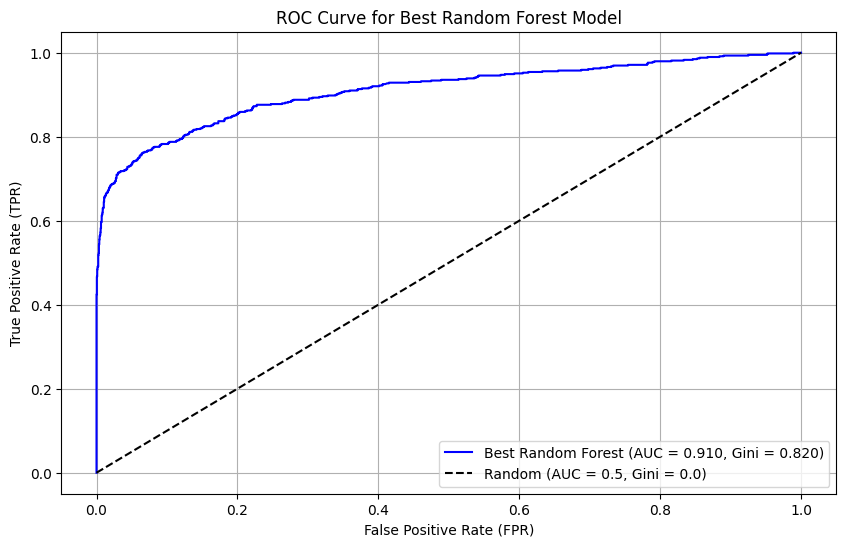

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import roc_curve, roc_auc_score
# from sklearn.model_selection import train_test_split
# import pandas as pd
# import joblib

# n_estimators_range = range(10, 501, 10)  # 10, 20, ..., 500
# max_depth_range = range(3, 9)            # 3, 4, ..., 8

# best_gini = -1
# best_model = None
# best_params = {}
# for n_estimators in n_estimators_range:
#     for max_depth in max_depth_range:
#         print(f"Training model with n_estimators={n_estimators}, max_depth={max_depth}...")

#         # Обучение модели
#         rf = RandomForestClassifier(
#             criterion='gini',
#             n_estimators=n_estimators,
#             max_depth=max_depth,
#             random_state=42
#         )
#         rf.fit(X_train, y_train)

#         # Предсказание вероятностей
#         y_probs = rf.predict_proba(X_test)[:, 1]

#         # ROC-AUC и Джини
#         auc_score = roc_auc_score(y_test, y_probs)
#         gini = 2 * auc_score - 1

#         # Сохранение лучшей модели
#         if gini > best_gini:
#             best_gini = gini
#             best_model = rf
#             best_params = {
#                 'n_estimators': n_estimators,
#                 'max_depth': max_depth,
#                 'auc_score': auc_score,
#                 'gini': gini
#             }

# # Сохраняем лучшую модель
# joblib.dump(best_model, 'best_random_forest_model.pkl')

# # Вывод лучших параметров
# print("\nBest Model Parameters:")
# print(f"n_estimators: {best_params['n_estimators']}")
# print(f"max_depth: {best_params['max_depth']}")
# print(f"AUC: {best_params['auc_score']:.4f}")
# print(f"Gini: {best_params['gini']:.4f}")

# # ROC-кривая для лучшей модели
# y_probs_best = best_model.predict_proba(X_test)[:, 1]
# fpr, tpr, thresholds = roc_curve(y_test, y_probs_best)

# # Построение графика
# plt.figure(figsize=(10, 6))
# plt.plot(fpr, tpr, label=f'Best Random Forest (AUC = {best_params["auc_score"]:.3f}, Gini = {best_params["gini"]:.3f})', color='blue')
# plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5, Gini = 0.0)')
# plt.xlabel('False Positive Rate (FPR)')
# plt.ylabel('True Positive Rate (TPR)')
# plt.title('ROC Curve for Best Random Forest Model')
# plt.legend()
# plt.grid()
# plt.show()

In [ ]:
TEST = pd.read_csv("target_test.csv")
for_test = data.drop(columns=["data",'data_2','data_3','data_4','data_5'])
for_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   inn                             15000 non-null  int64  
 1   name                            15000 non-null  object 
 2   region                          15000 non-null  int64  
 3   okved                           15000 non-null  int64  
 4   status_Действующая организация  15000 non-null  bool   
 5   status_Деятельность прекращена  15000 non-null  bool   
 6   status_Процесс банкротства      15000 non-null  bool   
 7   status_Процесс исключения       15000 non-null  bool   
 8   status_Процесс реорганизации    15000 non-null  bool   
 9   status_Стадия ликвидации        15000 non-null  bool   
 10  Закупки                         15000 non-null  int64  
 11  2020                            15000 non-null  float64
 12  2021                            

In [ ]:
merged_test = pd.merge(
    TEST,
    for_test,
    on='inn',      # Ключевой столбец
    how='left'     # Сохраняем все строки из train
)
# def count_zeros(row):
#     return (row == 0).sum()

merged_test = merged_test.drop(columns=['inn','name'])
merged_test

,region,okved,status_Действующая организация,status_Деятельность прекращена,status_Процесс банкротства,status_Процесс исключения,status_Процесс реорганизации,status_Стадия ликвидации,Закупки,2020,...,count_2021,sum_2021,count_2022,sum_2022,count_2023,sum_2023,count_2024,sum_2024,count_2025,sum_2025
0,99,58,True,False,False,False,False,False,437550,0.0,...,0,0.0,0,0.00,0,0.00,0,0.000000e+00,0,0.00
1,129,116,False,False,True,False,False,False,0,0.0,...,0,0.0,14,12368510.92,3,6678784.50,2,4.652933e+08,2,644571.12
2,96,651,True,False,False,False,False,False,12469999,0.0,...,0,0.0,0,0.00,0,0.00,0,0.000000e+00,0,0.00
3,181,444,True,False,False,False,False,False,3519776116,0.0,...,0,0.0,0,0.00,1,2100662.75,0,0.000000e+00,0,0.00
4,125,199,True,False,False,False,False,False,0,0.0,...,1,234349.0,0,0.00,3,1212747.78,4,4.145555e+06,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,36,297,True,False,False,False,False,False,0,0.0,...,0,0.0,1,846715.31,1,0.00,1,7.159169e+05,0,0.00
4496,21,638,True,False,False,False,False,False,2060425,0.0,...,0,0.0,0,0.00,0,0.00,0,0.000000e+00,0,0.00
4497,99,613,True,False,False,False,False,False,0,0.0,...,0,0.0,0,0.00,0,0.00,0,0.000000e+00,0,0.00
4498,156,596,True,False,False,False,False,False,609948754,0.0,...,0,0.0,0,0.00,0,0.00,2,2.000000e+03,0,0.00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
import pandas as pd
import joblib
rf = RandomForestClassifier(
            criterion='gini',
            n_estimators=160,
            max_depth=8,
            random_state=42
        )
rf.fit(X_train, y_train)

        # Предсказание вероятностей
y_probs = rf.predict_proba(X_test)[:, 1]

        # ROC-AUC и Джини
auc_score = roc_auc_score(y_test, y_probs)
gini = 2 * auc_score - 1
print(gini)
rf = RandomForestClassifier(
            criterion='gini',
            n_estimators=160,
            max_depth=8,
            random_state=42
        )
rf.fit(X_train, y_train)

        # Предсказание вероятностей
y_probs = rf.predict_proba(X_test)[:, 1]



0.6711171614569698


In [ ]:
[47]
y_res = rf.predict_proba(merged_test)[:, 1]

In [ ]:
y_res

array([0.06064739, 0.62001322, 0.06251248, ..., 0.05811585, 0.10020594,
       0.1050842 ])

In [ ]:
merged_t = pd.merge(
    TEST,
    for_test,
    on='inn',      # Ключевой столбец
    how='left'     # Сохраняем все строки из train
)


In [ ]:
result_df = pd.DataFrame({
    'inn': merged_t['inn'],  # Берем столбец 'inn' из merged_t
    'prediction': y_res      # Добавляем массив y_res как новый столбец
})

# Сохраняем в CSV (без индекса, кодировка UTF-8)
result_df.to_csv('output.csv', index=False, encoding='utf-8')

!!!Бустинг lightgbm

```
# Выбран кодовый формат
```



In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np

train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Параметры модели
params = {
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': ['binary_logloss', 'auc'],
    'num_leaves': 31,
    'learning_rate': 0.02,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

# 1. Кросс-валидация с ранней остановкой через callbacks
print("=== Кросс-валидация ===")
lgb_train = lgb.Dataset(X_train, y_train, free_raw_data=False)

# Используем early_stopping через callbacks
cv_results = lgb.cv(
    params,
    lgb_train,
    num_boost_round=1000,
    stratified=True,
    nfold=5,
    shuffle=True,
    seed=42,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(50)
    ]
)

best_rounds = len(cv_results['binary_logloss-mean'])
print(f"Лучшее количество итераций: {best_rounds}")
print(f"Лучшая logloss: {min(cv_results['binary_logloss-mean'])}")
print(f"Лучший AUC: {max(cv_results['auc-mean'])}")

# 2. Обучение с валидационным набором
print("\n=== Обучение с валидацией ===")
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

evals_result = {}
gbm = lgb.train(
    params,
    train_data,
    num_boost_round=best_rounds,
    valid_sets=[train_data, val_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),
        lgb.log_evaluation(50),
        lgb.record_evaluation(evals_result)
    ]
)

# 3. Оценка на тестовом наборе
print("\n=== Оценка на тестовых данных ===")
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration)
y_pred_class = (y_pred > 0.5).astype(int)

# Метрики
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))

accuracy = accuracy_score(y_test, y_pred_class)
print(f"\nAccuracy: {accuracy:.4f}")

auc_score = roc_auc_score(y_test, y_pred)
print(f"AUC: {auc_score:.4f}")
print(f"Gini: {2 * auc_score - 1:.4f}")

# 4. Визуализации
print("\n=== Визуализации ===")
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
lgb.plot_metric(evals_result, metric='binary_logloss', title='LogLoss during training')
plt.grid()

plt.subplot(1, 2, 2)
lgb.plot_importance(gbm, max_num_features=15, title='Feature Importance')
plt.tight_layout()
plt.show()

=== Кросс-валидация ===
Training until validation scores don't improve for 50 rounds
[50]	cv_agg's valid binary_logloss: 0.360305 + 0.0112001	cv_agg's valid auc: 0.860487 + 0.0205762
[100]	cv_agg's valid binary_logloss: 0.318177 + 0.0165972	cv_agg's valid auc: 0.862339 + 0.0207875


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
Accuracy: 0.8886
0.6798177068871869


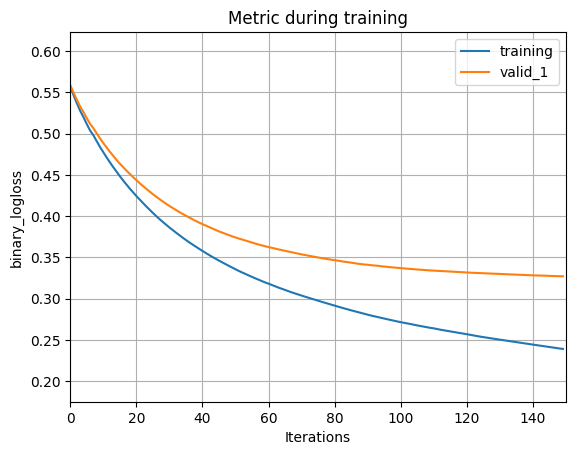

In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import json

# Создание Dataset для LightGBM
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Параметры модели
params = {
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': 'binary_logloss',
    'num_leaves': 31,
    'learning_rate': 0.02,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': 0
}


# Обучение модели с сохранением истории обучения
evals_result = {} # Словарь для хранения результатов оценки
gbm = lgb.train(params,
                train_data,
                num_boost_round=150,
                valid_sets=[train_data, test_data], # Наборы данных для оценки
                callbacks=[lgb.record_evaluation(evals_result)])

# Предсказание и оценка (как в вашем исходном коде)
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration)
y_pred_class = [1 if x > 0.5 else 0 for x in y_pred]
accuracy = accuracy_score(y_test, y_pred_class)
print(f"Accuracy: {accuracy:.4f}")

auc_score = roc_auc_score(y_test, y_pred)
gini = 2 * auc_score - 1
print(gini)

# Сохранение модели
gbm.save_model('lgbm_model.txt')

# Построение графика обучения
lgb.plot_metric(evals_result, metric='binary_logloss')
plt.show()

In [ ]:
X_train_

NameError: name 'X_train_' is not defined

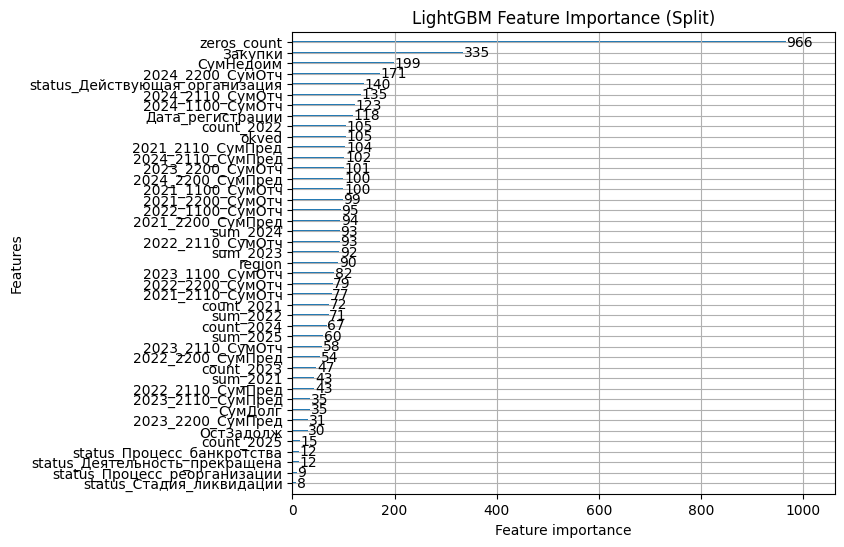

In [ ]:
from lightgbm import plot_importance
import matplotlib.pyplot as plt
plot_importance(gbm, importance_type="split", figsize=(7,6), title="LightGBM Feature Importance (Split)")
plt.show()

In [ ]:
TEST = pd.read_csv("target_test.csv")
for_test = data.drop(columns=["data",'data_2','data_3','data_4','data_5'])
merged_t = pd.merge(
    TEST,
    for_test,
    on='inn',      # Ключевой столбец
    how='left'     # Сохраняем все строки из train
)


In [ ]:
probs_boosting = gbm.predict(merged_test, num_iteration=gbm.best_iteration)

In [ ]:
probs_boosting

array([0.11532919, 0.962261  , 0.06757959, ..., 0.42961317, 0.06124205,
       0.4267308 ])

In [ ]:
result_df = pd.DataFrame({
    'inn': merged_t['inn'],  # Берем столбец 'inn' из merged_t
    'prediction': probs_boosting      # Добавляем массив y_res как новый столбец
})

# Сохраняем в CSV (без индекса, кодировка UTF-8)
result_df.to_csv('result_boosting.csv', index=False, encoding='utf-8')

CATBOOST

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.3 MB/s eta 0:00:00


Accuracy: 0.9171
Gini: 0.8326


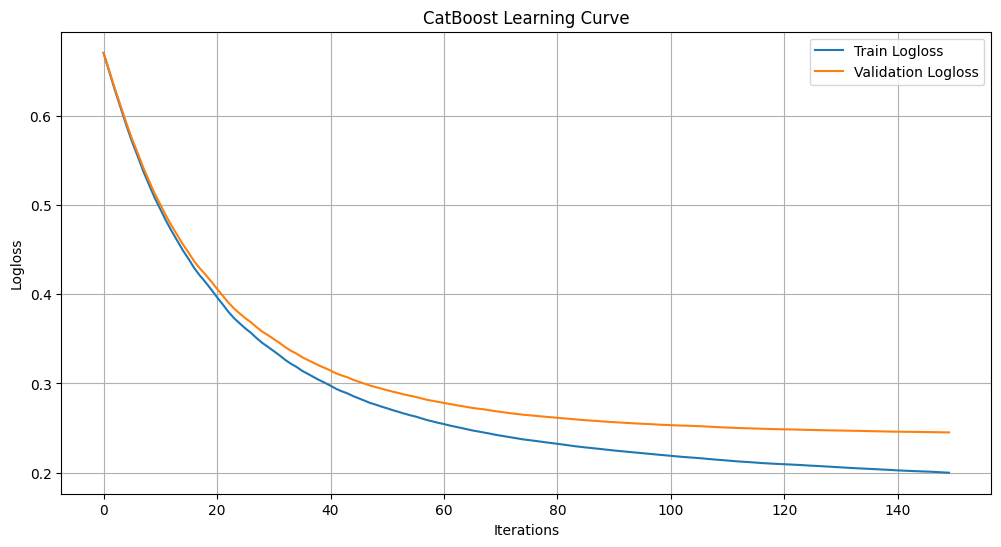

In [ ]:
from catboost import CatBoostClassifier, Pool
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Создание Pool для CatBoost
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

# Параметры модели
params = {
    'iterations': 150,
    'learning_rate': 0.02,
    'depth': 8,
    'loss_function': 'Logloss',
    'eval_metric': 'Logloss',
    'random_seed': 42,
    'logging_level': 'Silent',
    'use_best_model': True  # Использовать лучшую модель по валидации
}

# Обучение модели с сохранением истории
model = CatBoostClassifier(**params)
model.fit(
    train_pool,
    eval_set=test_pool,
    plot=False  # Отключаем встроенный график, будем строить свой
)

# Получение истории обучения
evals_result = model.get_evals_result()

# Предсказание и оценка
y_pred = model.predict_proba(X_test)[:, 1]
y_pred_class = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_class)
print(f"Accuracy: {accuracy:.4f}")

auc_score = roc_auc_score(y_test, y_pred)
gini = 2 * auc_score - 1
print(f"Gini: {gini:.4f}")

# Сохранение модели
model.save_model('catboost_model.cbm')

# Построение графиков обучения
plt.figure(figsize=(12, 6))

# График logloss
plt.plot(evals_result['learn']['Logloss'], label='Train Logloss')
plt.plot(evals_result['validation']['Logloss'], label='Validation Logloss')
plt.title('CatBoost Learning Curve')
plt.xlabel('Iterations')
plt.ylabel('Logloss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
probs_catboosting = model.predict(merged_test, prediction_type='Probability')[:, 1]
probs_catboosting


array([0.05235488, 0.07657547, 0.88300087, ..., 0.02682058, 0.39952782,
       0.26297115])

In [ ]:
result_df = pd.DataFrame({
    'inn': merged_t['inn'],  # Берем столбец 'inn' из merged_t
    'prediction': probs_catboosting      # Добавляем массив y_res как новый столбец
})

# Сохраняем в CSV (без индекса, кодировка UTF-8)
result_df.to_csv('result_catboosting.csv', index=False, encoding='utf-8')

XGBOOST

[0]	train-logloss:0.51591	validation-logloss:0.52150
[10]	train-logloss:0.42589	validation-logloss:0.44117
[20]	train-logloss:0.36403	validation-logloss:0.38745
[30]	train-logloss:0.31990	validation-logloss:0.35064
[40]	train-logloss:0.28591	validation-logloss:0.32332
[50]	train-logloss:0.25907	validation-logloss:0.30289
[60]	train-logloss:0.23788	validation-logloss:0.28751
[70]	train-logloss:0.22035	validation-logloss:0.27573
[80]	train-logloss:0.20616	validation-logloss:0.26670
[90]	train-logloss:0.19400	validation-logloss:0.25933
[100]	train-logloss:0.18340	validation-logloss:0.25390
[110]	train-logloss:0.17454	validation-logloss:0.24923
[120]	train-logloss:0.16639	validation-logloss:0.24553
[130]	train-logloss:0.15860	validation-logloss:0.24244
[140]	train-logloss:0.15187	validation-logloss:0.24018
[150]	train-logloss:0.14568	validation-logloss:0.23865
[160]	train-logloss:0.14045	validation-logloss:0.23722
[170]	train-logloss:0.13583	validation-logloss:0.23610
[180]	train-logloss:0

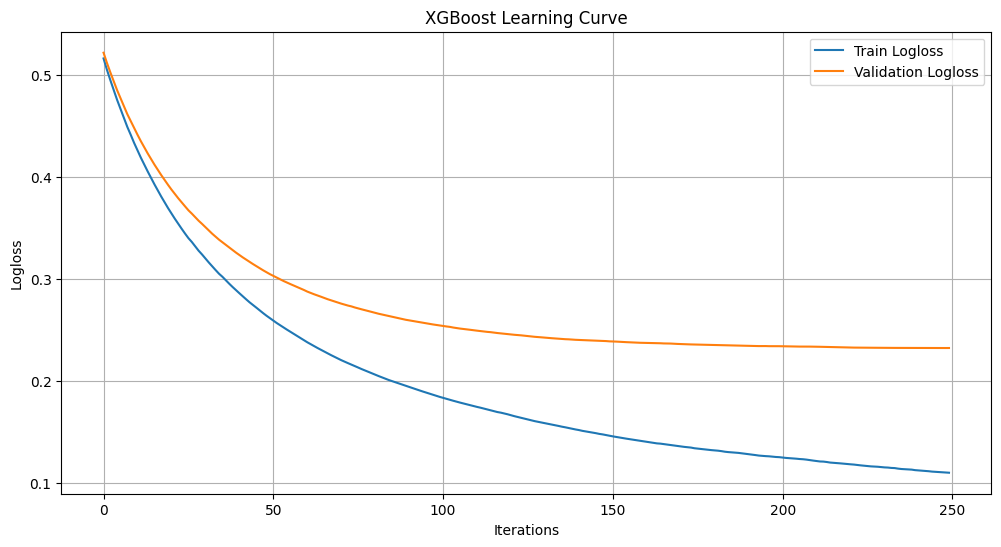

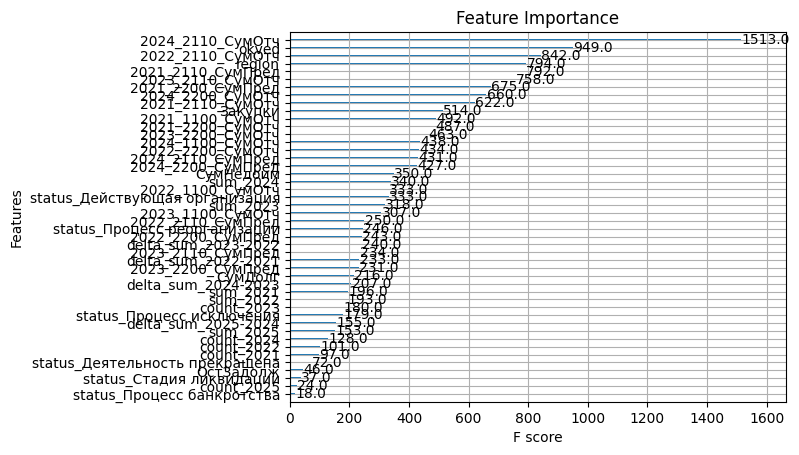

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score


# Создание DMatrix для XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Параметры модели
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 8,
    'learning_rate': 0.02,
    'subsample': 0.8,
    'colsample_bytree': 0.9,
    'seed': 42
}

# Обучение модели с сохранением истории
evals_result = {}
model = xgb.train(
    params,
    dtrain,
    num_boost_round=250,
    evals=[(dtrain, 'train'), (dtest, 'validation')],
    early_stopping_rounds=20,
    evals_result=evals_result,
    verbose_eval=10
)

# Предсказание и оценка
y_pred = model.predict(dtest)
y_pred_class = [1 if x > 0.5 else 0 for x in y_pred]
accuracy = accuracy_score(y_test, y_pred_class)
print(f"Accuracy: {accuracy:.4f}")

auc_score = roc_auc_score(y_test, y_pred)
gini = 2 * auc_score - 1
print(f"Gini: {gini:.4f}")

# Сохранение модели
model.save_model('xgboost_model.json')

# Построение графиков обучения
plt.figure(figsize=(12, 6))

# График logloss
plt.plot(evals_result['train']['logloss'], label='Train Logloss')
plt.plot(evals_result['validation']['logloss'], label='Validation Logloss')
plt.title('XGBoost Learning Curve')
plt.xlabel('Iterations')
plt.ylabel('Logloss')
plt.legend()
plt.grid()
plt.show()

# Визуализация важности признаков
xgb.plot_importance(model)
plt.title('Feature Importance')
plt.show()

In [ ]:
dtest = xgb.DMatrix(merged_test)
probs_XGboosting = model.predict(dtest, output_margin=False)
probs_XGboosting

array([0.05218966, 0.04200955, 0.97022927, ..., 0.01038337, 0.27780277,
       0.09532142], dtype=float32)

In [ ]:
result_df = pd.DataFrame({
    'inn': merged_t['inn'],  # Берем столбец 'inn' из merged_t
    'prediction': probs_XGboosting      # Добавляем массив y_res как новый столбец
})

# Сохраняем в CSV (без индекса, кодировка UTF-8)
result_df.to_csv('result_XGboosting.csv', index=False, encoding='utf-8')

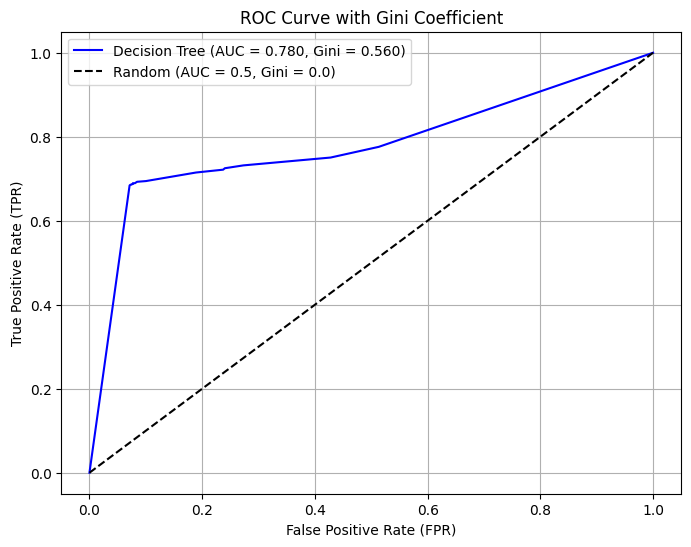

AUC: 0.7798
Gini: 0.5595


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score


dt = DecisionTreeClassifier(
    max_depth=20,
    random_state=42,
    criterion='gini'
)
dt.fit(X_train, y_train)


y_probs = dt.predict_proba(X_test)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Критерий Джини
gini = 2 * auc_score - 1

# Строим график
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {auc_score:.3f}, Gini = {gini:.3f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5, Gini = 0.0)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve with Gini Coefficient')
plt.legend()
plt.grid()
plt.show()

print(f"AUC: {auc_score:.4f}")
print(f"Gini: {gini:.4f}")

In [ ]:
thresholds

array([       inf, 1.        , 0.98360656, 0.97272727, 0.8       ,
       0.52173913, 0.5       , 0.45454545, 0.36363636, 0.33333333,
       0.27272727, 0.24285714, 0.17258883, 0.16923077, 0.16862745,
       0.15242494, 0.14705882, 0.11885246, 0.11764706, 0.11561119,
       0.09700176, 0.09480969, 0.08695652, 0.08617021, 0.07407407,
       0.06097561, 0.05555556, 0.04      , 0.        ])

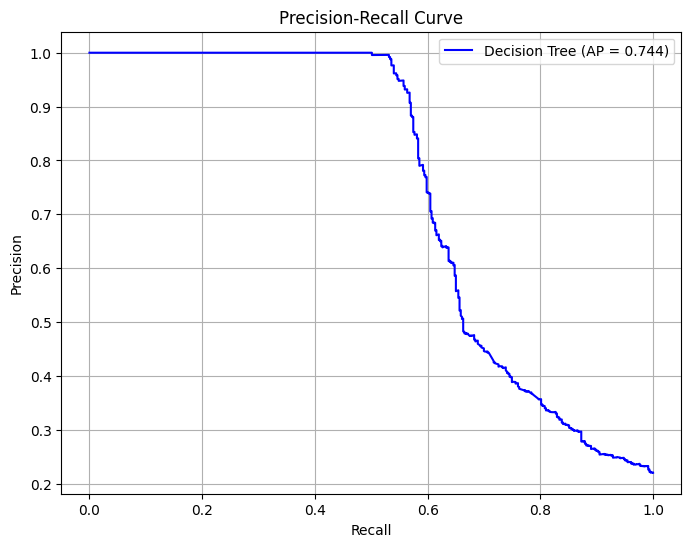

Average Precision: 0.7440


In [ ]:
import shap
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Обучаем дерево решений
dt = RandomForestClassifier(criterion='gini',n_estimators=500, random_state=42,max_depth = 5)
dt.fit(X_train, y_train)

# Предсказанные вероятности для положительного класса
y_probs = dt.predict_proba(X_test)[:, 1]

# Precision-Recall кривая и Average Precision
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)

# tree_explainer = shap.Explainer(dt, X_train)
# tree_shap_values = tree_explainer(X_test)

# shap.summary_plot(tree_shap_values, X_test)
# Строим график
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Decision Tree (AP = {ap_score:.3f})', color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

print(f"Average Precision: {ap_score:.4f}")